## Distribuciones muestrales: El teorema del límite central.
> ### **Distribución muestral**
> 
> La distribución muestral de un estadístico es la distr. de probabilidad que especifica probabilidades para los posibles valores del estadístico.

Dado que la media muestral es bastante ubicua, y la porporción muestral es también una media muestral de datos (0, 1), nos enfocaremos en la distribución muestral de esta. ¿Qué forma esperaríamos tener?

Veamos un ejemplo intuitivo, distribución uniforme sobre $\{1, 2, 3, 4, 5, 6\}$, i.e., lanzamiento de un dado. Si lanzamos el dado 15 veces y calculamos $\bar{Y}$. ¿Qué valores esperaríamos?, sería raro que $\bar{Y}$ estuviera cerca de 1.0 así como de 6.0. Lo que no sería sorprendente es que se encuentre cerca de la mitad del rango, como entre 3 y 4. Por lo que intuitivamente esperaríamos que la distribución muestral de $\bar{Y}$ tenga una cierta forma de campana.

El teorema del límite central es un resultado con grandes implicaciones para inferencia estadística: En estudios que usan aleatorización (randomization), _sin importar la forma de la distribución de la población, la distribución de $\bar{Y}$ es aproximadamente normal_.

> ### Teorema del límite central
> Para un número grande _n_ de observaciones independientes de una población con distribución con media $\mu$ y desviación estándar $\sigma<\infty$, la distribución muestral de la media muestral $\bar{Y}$ es aprox. normal con media $\mu$ y desviación estándar $\sigma_{\bar{Y}}=\sigma/\sqrt{n}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta
from scipy.stats import expon

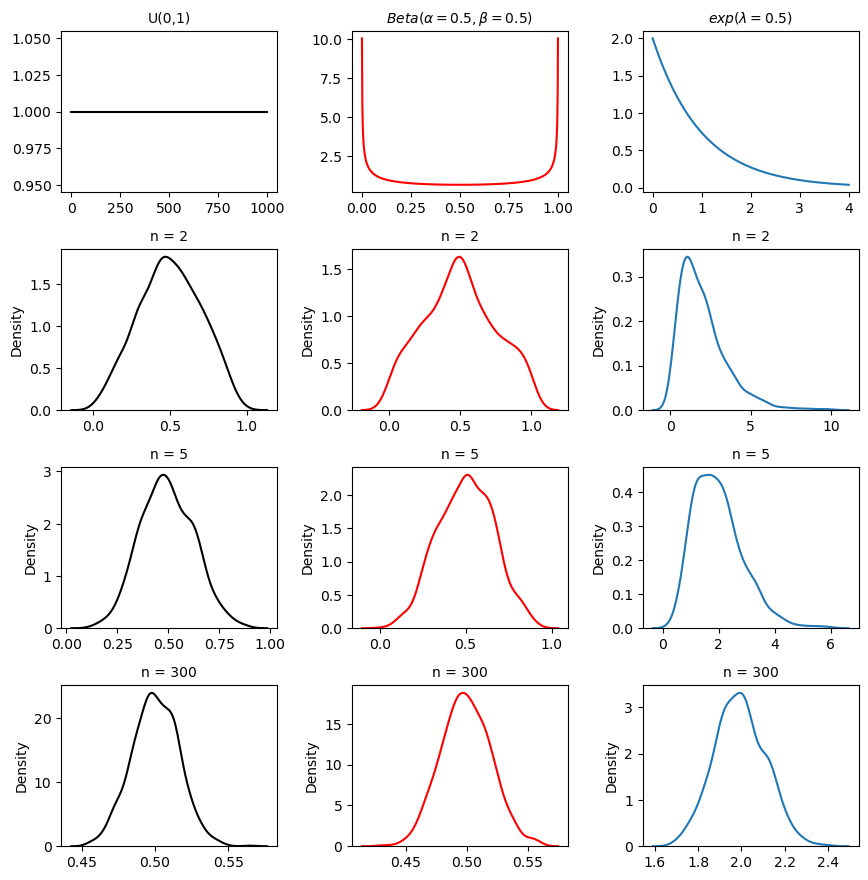

In [2]:
n = [2, 5, 300]
x = np.zeros((3, 1000, 3))
for j in range(0,3):
    x[0,:,j] = np.array([np.mean(s) for s in np.random.rand(1000, n[j])])
    x[1,:,j] = np.array([np.mean(s) for s in np.random.beta(a = 0.5, b = 0.5, size = (1000, n[j]))])
    x[2,:,j] = np.array([np.mean(s) for s in np.random.exponential(scale = 2, size = (1000, n[j]))])
fig, axs = plt.subplots(4, 3)
fig.set_figwidth(9)
fig.set_figheight(9)
fig.tight_layout(pad=2.0)
axs[0,0].plot(np.ones(1000), color = 'black')
axs[0,0].set_title('U(0,1)', fontsize = 10)
lspc = np.linspace(0,1,1000)
axs[0,1].plot(lspc, beta.pdf(lspc, 0.5, 0.5), color = 'red')
axs[0,1].set_title(r'$Beta(\alpha =0.5, \beta = 0.5)$', fontsize = 10)
lspc = np.linspace(0,4,1000)
axs[0,2].plot(lspc, 2*expon.pdf(lspc))
axs[0,2].set_title(r'$exp(\lambda = 0.5)$', fontsize = 10)
for i in range(0,3):
    m = n[i]
    sns.kdeplot(x[0,:,i], ax = axs[i+1, 0], color = 'black')
    axs[i+1, 0].set_title(f'n = {m:.0f}', fontsize = 10)
    sns.kdeplot(x[1,:,i], ax = axs[i+1, 1], color = 'red')
    axs[i+1, 1].set_title(f'n = {m:.0f}', fontsize = 10)
    sns.kdeplot(x[2,:,i], ax = axs[i+1, 2])
    axs[i+1, 2].set_title(f'n = {m:.0f}', fontsize = 10)

Hay algunos puntos a remarcar de este resultado:
- La normalidad aproximada de la distribución muestral aplica **sin importar la forma** de la distribución poblacional (siempre y cuando cumpla con las hipótesis del teorema).
- Como muchas cosas en estadística, qué tan largo debe ser $n$ para alcanzar una buena aproximación normal depende del problema. Intuitivamente si la distribución poblacional tiene forma de campana entonces la distribución muestral tiene forma de campana _para toda n_. Luego, qué tan grande debe ser la muestra depende de la asimetría de la distribución poblacional. Para casos usuales (sin asimetría severa) un tamaño demuesta de $\approx30$ es suficiente.
- Saber que la distribución muestral de $\bar{Y}$ es aproximadamente normal nos ayuda a encontrar probabilidades para posibles valores de $\bar{Y}$. Por ejemplo, para $n$ grande, $\bar{Y}$ muy seguramente se encuentra a una distancia de $3\sigma_{\bar{Y}}=3\sigma/\sqrt{n}$ de $\mu$.
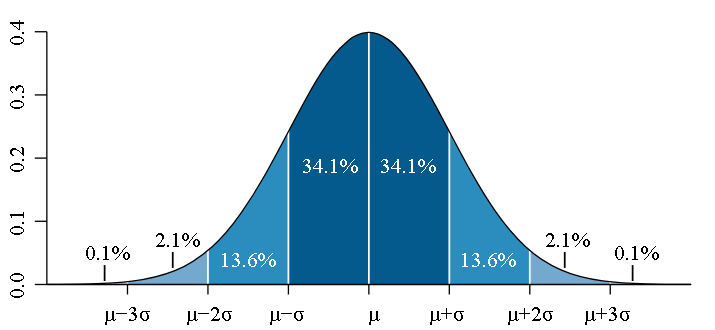

## Ejercicio
### Predecir el resultado de una elección con base en encuesta de salida
Para elecciones grandes, agencias de medios utilizan encuestas de salida de votantes para ayudar a predecir el/la ganador/a antes de que se cuenten los votos. Para la elección presidencial de 2020 de Estados Unidos, en un cuestionario de salida de votantes de California se obtuvo que el $65.5\%$ contestó haber votado por Biden. La muestra fue solo de 2271 votantes de una población adulta de 17 M. Con esto se predijo que Biden ganaría California y obtendría sus votos del colegio electoral. ¿Cómo esta encuesta de salida del $0.01\%$ podría tener suficiente información para predecir el ganador?
A través de simulación ¿Cómo se podría decidir si Biden ganó el estado de California con base en esta muestra?

### Solución
Simulamos los resultados de una encuesta de salida como aquella que se obtuvo en 2020. En el caso de que la probabilidad es $p=0.5$ de que se haya votado por Joe Biden. 

In [3]:
n, p = 2271, 0.5    # n es el nro. de personas encuestadas en 2020, p = 0.5 es la prob. hipotética/ficticia
x = np.random.binomial(n, p, 1)    # simulamos una sola encuesta
print(x); print(x/n)    # nro. de votantes por Biden/ proporción respecto a la muestra de 2271

[1119]
[0.49273448]


Ahora repetimos el proceso de muestrear aleatoriamente 2271 votantes, un millón de veces, **para investigar la variabilidad en los resultados de la proporción simulada**. 

- Cada votante es una realización de una v. a. Bernoulli de parámetro $p$.
- La proporción de votantes por Biden es el resultado de la encuesta, calculado como el promedio $\bar{Y}=\frac{1}{n}Y_i$.
- $n=2271$ porque este es el nro. de personas encuestadas.
- Este es un número suficientemente grande como para ver que su promedio, $\bar{Y}$, se distribuye aproximadamente normal.
- Simular la encuesta es simular 2271 v. a. Bernoulli y contar el nro. de 1's.
- O, más fácil, simular **una** v. a. binomial de parámetros $n=2271$ y $p=0.5$.
- Cada una de estas simulaciones nos dará el nro. de votos a favor, del total de 2271.
- Para obtener la proporción dividimos entre $n=2271$.

Text(0.5, 0, 'Proporción de la muestra')

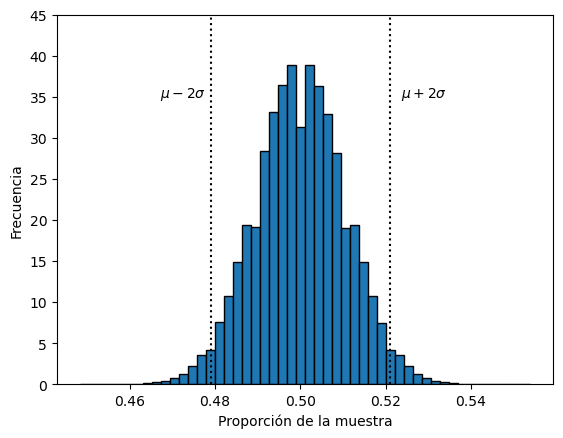

In [4]:
resultados = np.random.binomial(n, p, 1000000)/n
np.mean(resultados)
np.std(resultados)
u_2s = np.mean(resultados)+2*np.std(resultados)
u__2s = np.mean(resultados)-2*np.std(resultados)
plt.vlines(u_2s, 0, 45, linestyles = 'dotted', colors = 'k')
plt.vlines(u__2s, 0, 45, linestyles = 'dotted', colors = 'k')
plt.hist(resultados, bins = 50, edgecolor = 'k', density = True)
plt.text(u_2s*1.005, 35, r'$\mu+2\sigma$')
plt.text(u__2s*0.975, 35, r'$\mu-2\sigma$')
plt.ylim((0,45))
plt.ylabel('Frecuencia')
plt.xlabel('Proporción de la muestra')

In [5]:
x = np.append(np.zeros(int((1-0.635)*1000)), np.ones(int(0.635*1000)))
d = np.random.binomial(n,0.635,1000000)/n

Text(0.2, 22, 'Distribución poblacional')

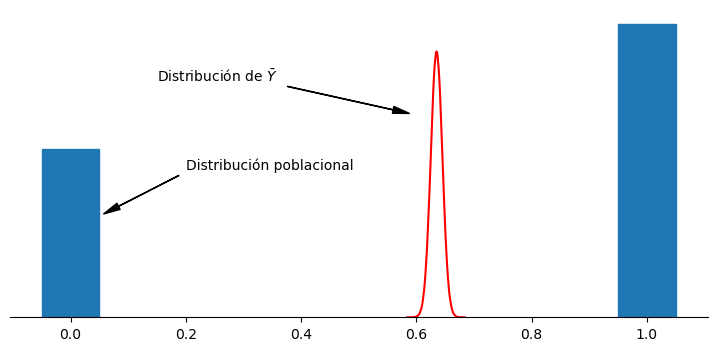

In [6]:
plt.figure(figsize = (9, 4))
ax = plt.subplot(111)
ax.fill_between(np.linspace(-0.05, 0.05, 5), 25*np.ones(5), color = 'tab:blue')
ax.fill_between(np.linspace(0.95, 1.05, 5), 43.5*np.ones(5), color = 'tab:blue')
sns.kdeplot(d, ax = ax, color = 'red')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set(yticklabels=[])
ax.tick_params(left=False)
ax.set_ylabel('')
ax.annotate(r'Distribución de $\bar{Y}$', xy=(0.6, 30), xytext=(0.15, 35), arrowprops=dict(facecolor='black', shrink=0.05, 
                                                                                          width = 0.2, headwidth = 5))
ax.annotate('Distribución poblacional', xy=(0.05, 15), xytext=(0.2, 22), arrowprops=dict(facecolor='black', shrink=0.05, 
                                                                                          width = 0.2, headwidth = 5))

Algunas notas adicionales de la normalidad asintótica.
- El teorema del límite central es importante también porque un resultado similar es válido de manera más general.
- Muchos estadísticos (además de la media) utilizados para estimar parámetros poblacionales tienen distribuciones muestrales aproximadamente normales, para muesstras aleatorias de tamaño razonable.
- ### El método delta
  Sea $T$ un estadístico que tenga una distribución muestral aproximadamente normal, alrededor de una media $\theta$. Muchos estadísticos así tienen errores estándares que decrecen con $n$ como $1/\sqrt{n}$. Así que supongamos que $T$ tiene error estándar $\tau/\sqrt{n}$ para alguna cte. $\tau$. O sea, $T$ tiene aproximadamente una distr. $N(\theta, \tau^2/n)$, y por lo tanto, $\sqrt{n}(T-\theta)$ tiene una distr. de muestra grande $N(0,\tau^2)$. Ciertamente esta situación incluye el caso $T=\bar{Y}$, con $\theta=\mu$ y $\tau=\sigma$.

  Ahora, si el estadístico $g(T)$ es una función suave de $T$ entonces también tiene una distribución muestral aproximadamente normal.

  De la expansión en serie de Taylor para $g(t)$ en una vecindad de $t=\theta$
  $$
    \sqrt{n}\left[g(T)-g(\theta)\right]\approx\sqrt{n}\left(T-\theta\right)g'(\theta)\text{,}
  $$
  para $n$ grande, $g'(\theta)=dg(t)/dt|_{t=\theta}$. Como es usual en estas aproximaciones, para $n$ grande los términos de orden superior en la expansión son despreciables, dado que $T$ converge hacia $\theta$.

  Ahora recordemos que si $Y\sim N(0,\sigma^2)$, entonces $cY\sim N(0,c^2\sigma^2)$. Por la convergencia en distribución de $\sqrt{n}\left(T-\theta\right)$ a $N(0,\tau^2)$, tomando $c=g'(\theta)$ tenemos que la aproximación anterior implica que
  $$
    \sqrt{n}\left[g(T)-g(\theta)\right]\overset{d}{\rightarrow}N\left(0,[g'(\theta)]^2\tau^2\right)\text{.}
  $$
  La distr. muestral de $g(T)$ es aproximadamente normal con media $g(\theta)$ y var. $\left[g'(\theta)\right]^2\tau^2/n$. A este resultado se le conoce como **método delta**, por el rol que juega la derivada.

  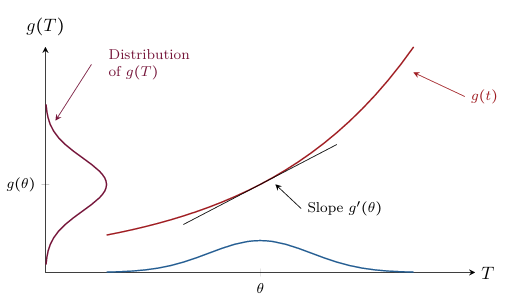


- ### _Normalidad asintótica del estimador máximo verosímil_

  **Teorema**
  
  Si la densidad $f(x;\theta)$ satisface ciertas condiciones de regularidad y si $\hat{\Theta}_n=\hat{\theta}_n(X_1,...X_n)$ es el estimador máxima verosimilitud de $\theta$ para una muestra aleatoria de tamaño $n$ de $f(x;\theta)$ entonces:
    - $\hat{\Theta}_n$ es asintóticamente normal distribuido con media $\theta$ y varianza
      $$
        \frac{1}{n}\mathbb{E}_\theta\left[\left[\frac{\partial}{\partial\theta}\ln f(X;\theta)\right]^2\right]\text{.}
      $$
    - La sucesión de estimadores máximo verosímiles $\hat{\Theta}_1, \hat{\Theta}_2, ..., \hat{\Theta}_n, ...$ es el "mejor" asintóticamente normal (consistente asintóticamente normal y eficiente).
- Para la derivación de este resultado se usa también, entre muchas otras cosas, el teorema del límite central.

### _Sin embargo, no todos los estadísticos tienen la característica de que al incrementarse $n$, se distribuyen aprox. normal_
Exploremos la distribución de la mediana muestral de una v.a. Poisson. Para esto simularemos un gran número de muestras aleatorias de esta distr. y después construiremos un histograma de los valores del estadístico.

In [7]:
x = np.random.poisson(lam = 0.7, size = 10)
np.median(x)

np.float64(0.5)

Ahora simulamos 100k muestras aleatorias de tamaño 10, cada una de la distr. Poisson mencionada.

In [8]:
x = np.random.poisson(lam = 0.7, size = (100000, 10))
xs = np.median(x, axis = 1)

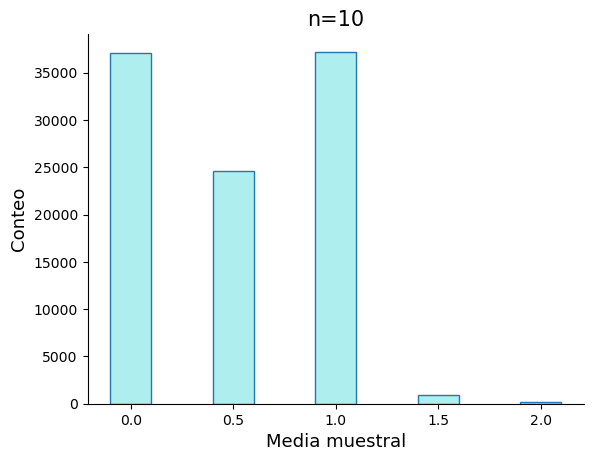

In [9]:
labels , counts = np.unique(xs, return_counts=True)
plt.bar(labels, counts, width = 0.2, align='center', edgecolor = 'tab:blue', color = 'paleturquoise')
plt.title('n=10', fontsize = 10)
plt.ylabel('Conteo', fontsize = 13)
plt.xlabel('Media muestral', fontsize = 13)
plt.title('n=10', fontsize = 15)
ax = plt.subplot(111)
ax.spines[['right', 'top']].set_visible(False)

In [10]:
x = np.random.poisson(lam = 0.7, size = (100000, 10000))
xs = np.median(x, axis = 1)

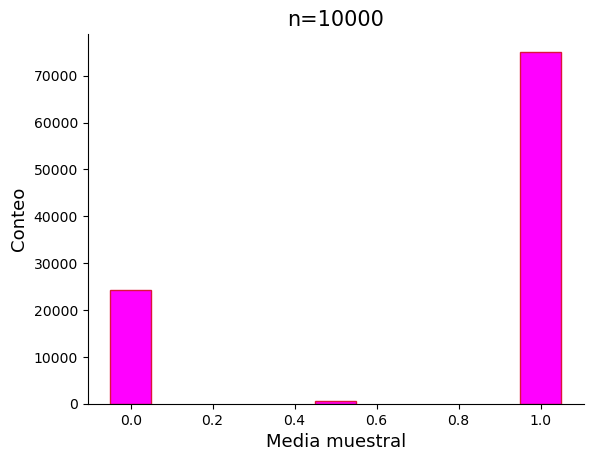

In [11]:
labels , counts = np.unique(xs, return_counts=True)
plt.bar(labels, counts, width = 0.1, align='center', edgecolor = 'crimson', color = 'magenta')
plt.ylabel('Conteo', fontsize = 13)
plt.xlabel('Media muestral', fontsize = 13)
plt.title('n=10000', fontsize = 15)
ax = plt.subplot(111)
ax.spines[['right', 'top']].set_visible(False)